# 3. Extract phase features — corrected

Mean skin temperature is calculated using the four-site ISO weighting stated in the manuscript. Test-relative descriptive changes use the mean of the first 60 s of the initial standing phase. The phase-specific baseline used for Table 3 remains a separate analysis in notebook 6.


In [6]:
from pathlib import Path
import sys

def find_project_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "data").exists() or (candidate / ".git").exists() or (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError("Project root not found. Run the notebook from inside the project repository.")

def ensure_dir(path: Path) -> Path:
    path.mkdir(parents=True, exist_ok=True)
    return path

def report_dir(root: Path, analysis_name: str, subfolder: str | None = None) -> Path:
    base = root / "reports" / analysis_name
    return ensure_dir(base if subfolder is None else base / subfolder)

ROOT = find_project_root()
print("ROOT:", ROOT)


ROOT: /home/eleonorab/repository/convective_cooling


In [7]:
from pathlib import Path
import numpy as np
import pandas as pd


ROOT = find_project_root()
INPUT_FILE = ROOT / "data" / "processed" / "analysis" / "analysis_dataset_wide.csv"
OUTPUT_DIR = ROOT / "data" / "processed" / "features"
ensure_dir(OUTPUT_DIR)

PHASE_ORDER = [
    "standing_1", "walk_low_1", "walk_mod_1",
    "walk_low_2", "walk_mod_2", "standing_2",
]

SKIN_TEMPERATURE_WEIGHTS = {
    "t_neck": 0.28,
    "t_scapula": 0.28,
    "t_hand": 0.16,
    "t_shin": 0.28,
}

TEST_BASELINE_SECONDS = 60.0


def load_data() -> pd.DataFrame:
    if not INPUT_FILE.exists():
        raise FileNotFoundError(f"Missing input file: {INPUT_FILE}")
    data = pd.read_csv(INPUT_FILE)
    for column in ["elapsed_minutes", "elapsed_seconds", *SKIN_TEMPERATURE_WEIGHTS]:
        if column in data:
            data[column] = pd.to_numeric(data[column], errors="coerce")
    data["condition"] = data["condition"].astype(str).str.strip().str.lower()
    data["subject_id"] = data["subject_id"].astype(str).str.strip()
    data["phase"] = data["phase"].astype(str).str.strip()
    return data


def add_mean_skin_temperature(data: pd.DataFrame) -> pd.DataFrame:
    missing = [column for column in SKIN_TEMPERATURE_WEIGHTS if column not in data]
    if missing:
        raise KeyError(
            "The ISO-weighted mean skin temperature requires all four sites. "
            f"Missing columns: {missing}. Check notebook 1 and the raw signal files."
        )

    data = data.copy()
    weighted_terms = [
        weight * data[column]
        for column, weight in SKIN_TEMPERATURE_WEIGHTS.items()
    ]
    # Ordinary addition intentionally returns NaN if any required site is missing.
    data["mean_skin_temperature"] = sum(weighted_terms)
    return data


def get_signal_columns(data: pd.DataFrame) -> list[str]:
    excluded = {
        "subject_id", "condition", "timestamp", "elapsed_seconds",
        "elapsed_seconds_bin", "elapsed_minutes", "phase", "time_bin_5min",
    }
    return [column for column in data.columns if column not in excluded]


def compute_test_baselines(data: pd.DataFrame, signals: list[str]) -> pd.DataFrame:
    baseline_window = data.loc[
        (data["phase"] == "standing_1")
        & (data["elapsed_seconds"] <= TEST_BASELINE_SECONDS)
    ].copy()

    rows = []
    for (subject, condition), group in baseline_window.groupby(
        ["subject_id", "condition"], observed=True
    ):
        for signal in signals:
            values = pd.to_numeric(group[signal], errors="coerce")
            rows.append({
                "subject_id": subject,
                "condition": condition,
                "signal": signal,
                "baseline_value": values.mean(),
                "baseline_n": int(values.notna().sum()),
            })
    return pd.DataFrame(rows)


def compute_slope(x: np.ndarray, y: np.ndarray) -> float:
    valid = np.isfinite(x) & np.isfinite(y)
    if valid.sum() < 2:
        return np.nan
    return float(np.polyfit(x[valid], y[valid], 1)[0])


def extract_phase_features(
    data: pd.DataFrame,
    signals: list[str],
    baselines: pd.DataFrame,
) -> pd.DataFrame:
    lookup = baselines.set_index(
        ["subject_id", "condition", "signal"]
    )["baseline_value"].to_dict()

    rows = []
    for (subject, condition, phase), group in data.groupby(
        ["subject_id", "condition", "phase"], observed=True
    ):
        group = group.sort_values("elapsed_minutes")
        for signal in signals:
            values = pd.DataFrame({
                "time": pd.to_numeric(group["elapsed_minutes"], errors="coerce"),
                "value": pd.to_numeric(group[signal], errors="coerce"),
            }).dropna()
            if values.empty:
                continue

            baseline = lookup.get((subject, condition, signal), np.nan)
            mean_value = values["value"].mean()
            rows.append({
                "subject_id": subject,
                "condition": condition,
                "phase": phase,
                "signal": signal,
                "n_samples": len(values),
                "mean": mean_value,
                "std": values["value"].std(),
                "median": values["value"].median(),
                "min": values["value"].min(),
                "max": values["value"].max(),
                "delta_in_out": values["value"].iloc[-1] - values["value"].iloc[0],
                "slope": compute_slope(
                    values["time"].to_numpy(float), values["value"].to_numpy(float)
                ),
                "baseline_value": baseline,
                "delta_mean_from_baseline": (
                    mean_value - baseline if pd.notna(baseline) else np.nan
                ),
            })

    output = pd.DataFrame(rows)
    if not output.empty:
        output["phase"] = pd.Categorical(
            output["phase"], categories=PHASE_ORDER, ordered=True
        )
        output = output.sort_values(
            ["signal", "condition", "subject_id", "phase"]
        ).reset_index(drop=True)
    return output


def main() -> None:
    data = add_mean_skin_temperature(load_data())
    signals = get_signal_columns(data)
    baselines = compute_test_baselines(data, signals)
    phase_features = extract_phase_features(data, signals, baselines)

    data.to_csv(OUTPUT_DIR / "analysis_dataset_with_tsk.csv", index=False)
    baselines.to_csv(OUTPUT_DIR / "baseline_values.csv", index=False)
    phase_features.to_csv(OUTPUT_DIR / "phase_features_long.csv", index=False)

    print("Saved:")
    print(OUTPUT_DIR / "analysis_dataset_with_tsk.csv")
    print(OUTPUT_DIR / "baseline_values.csv")
    print(OUTPUT_DIR / "phase_features_long.csv")
    print("Mean-skin-temperature valid rows:", data["mean_skin_temperature"].notna().sum())


if __name__ == "__main__":
    main()


Saved:
/home/eleonorab/repository/convective_cooling/data/processed/features/analysis_dataset_with_tsk.csv
/home/eleonorab/repository/convective_cooling/data/processed/features/baseline_values.csv
/home/eleonorab/repository/convective_cooling/data/processed/features/phase_features_long.csv
Mean-skin-temperature valid rows: 8795


## Mean time series across participants

Absolute temperature and relative-humidity time series (mean ± 1 SD across participants) for the dorsal site, mean skin and garment microclimate.


Loading data from: /home/eleonorab/repository/convective_cooling/data/processed/analysis/analysis_dataset_wide.csv
Replaced 13 isolated one-sample artefacts before plotting.
Spike audit saved to: outputs/isolated_spike_audit.csv


/home/eleonorab/.local/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/eleonorab/.local/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


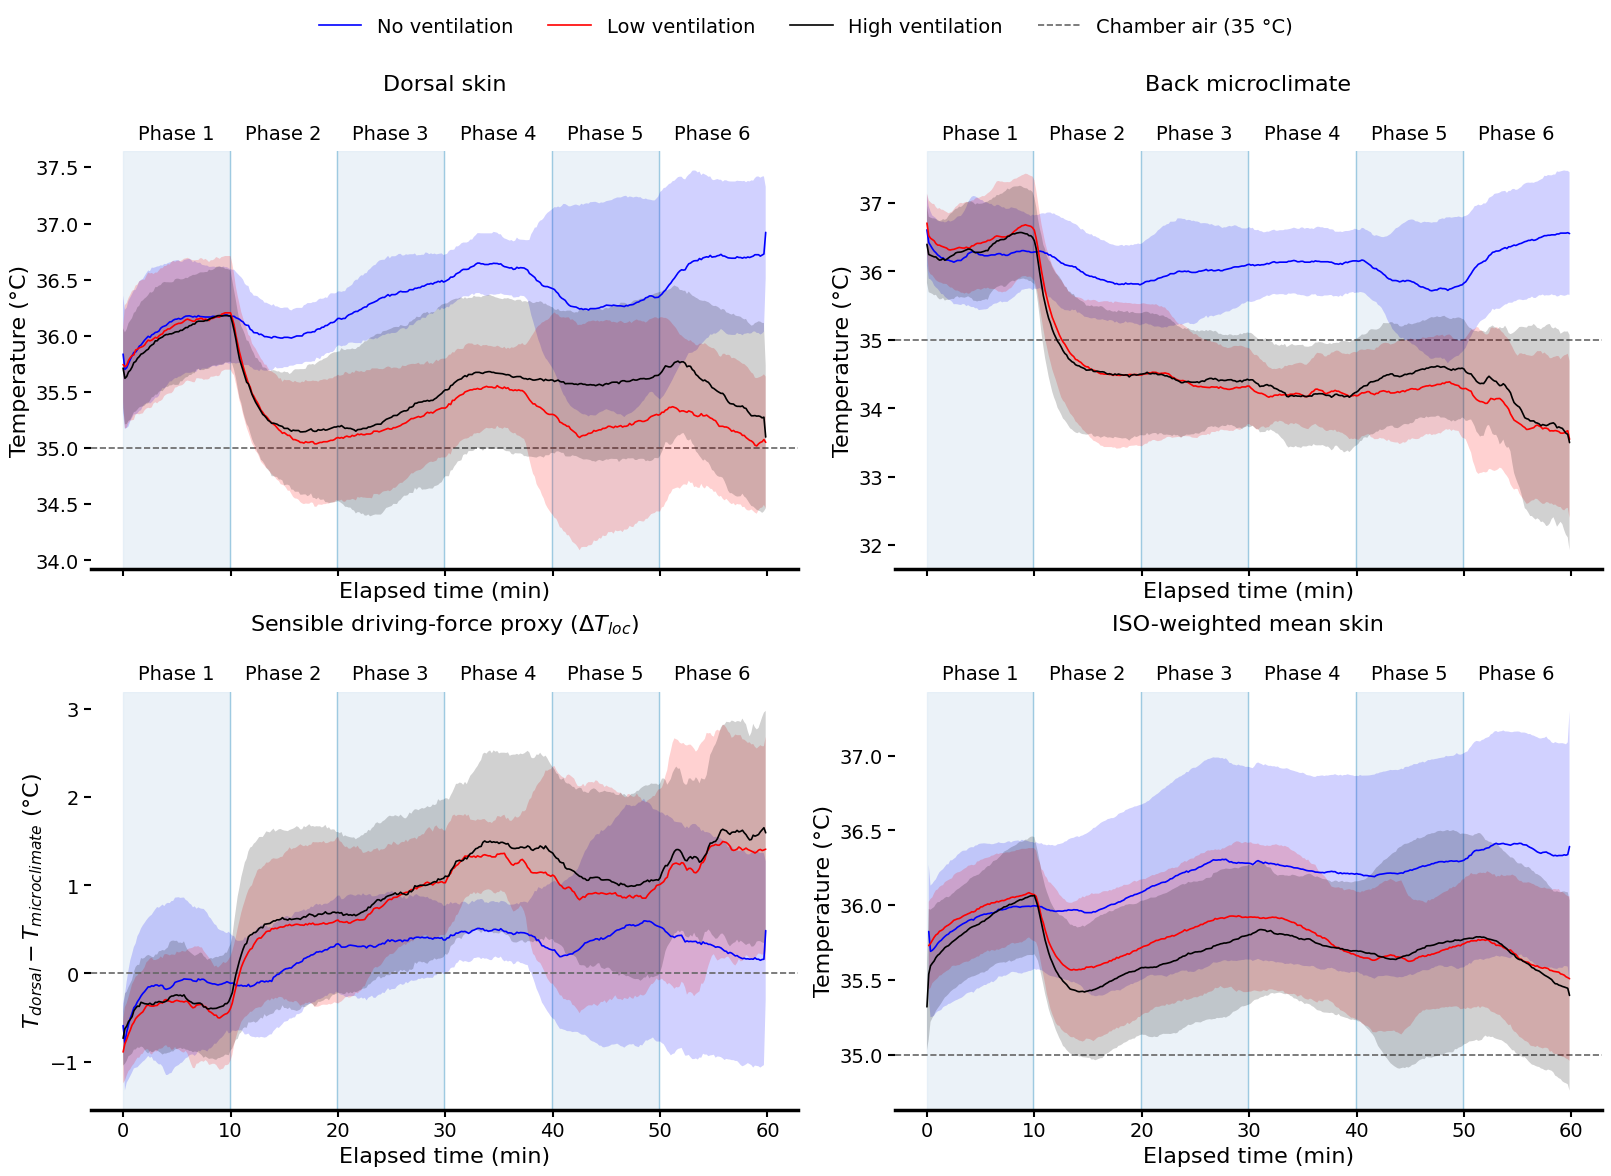

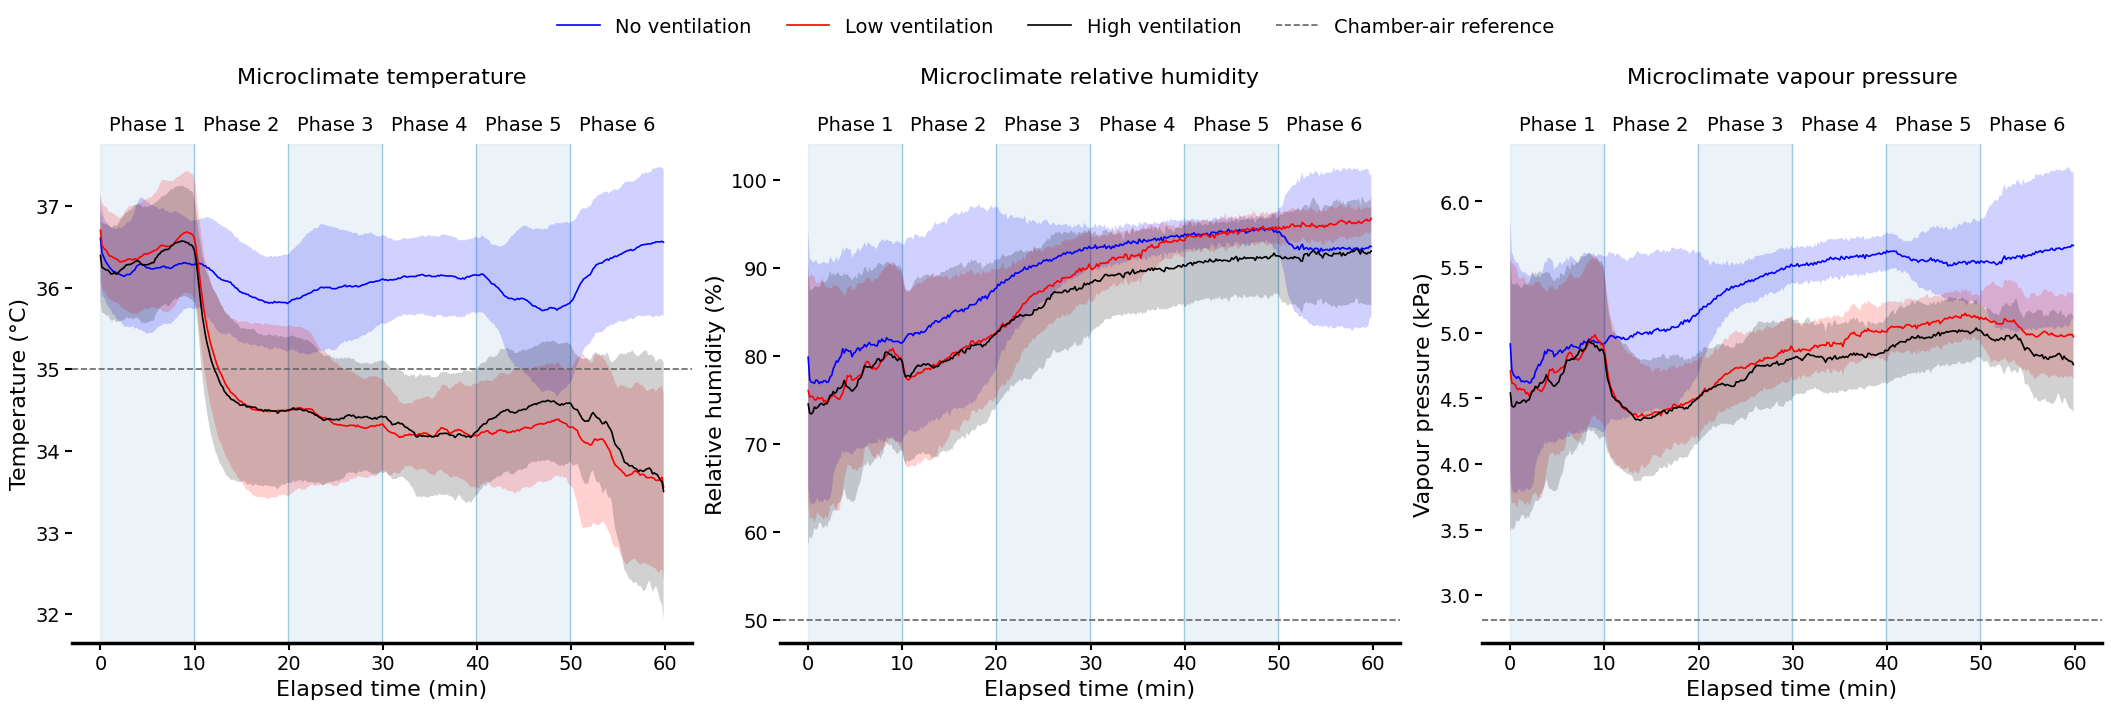

/home/eleonorab/.local/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


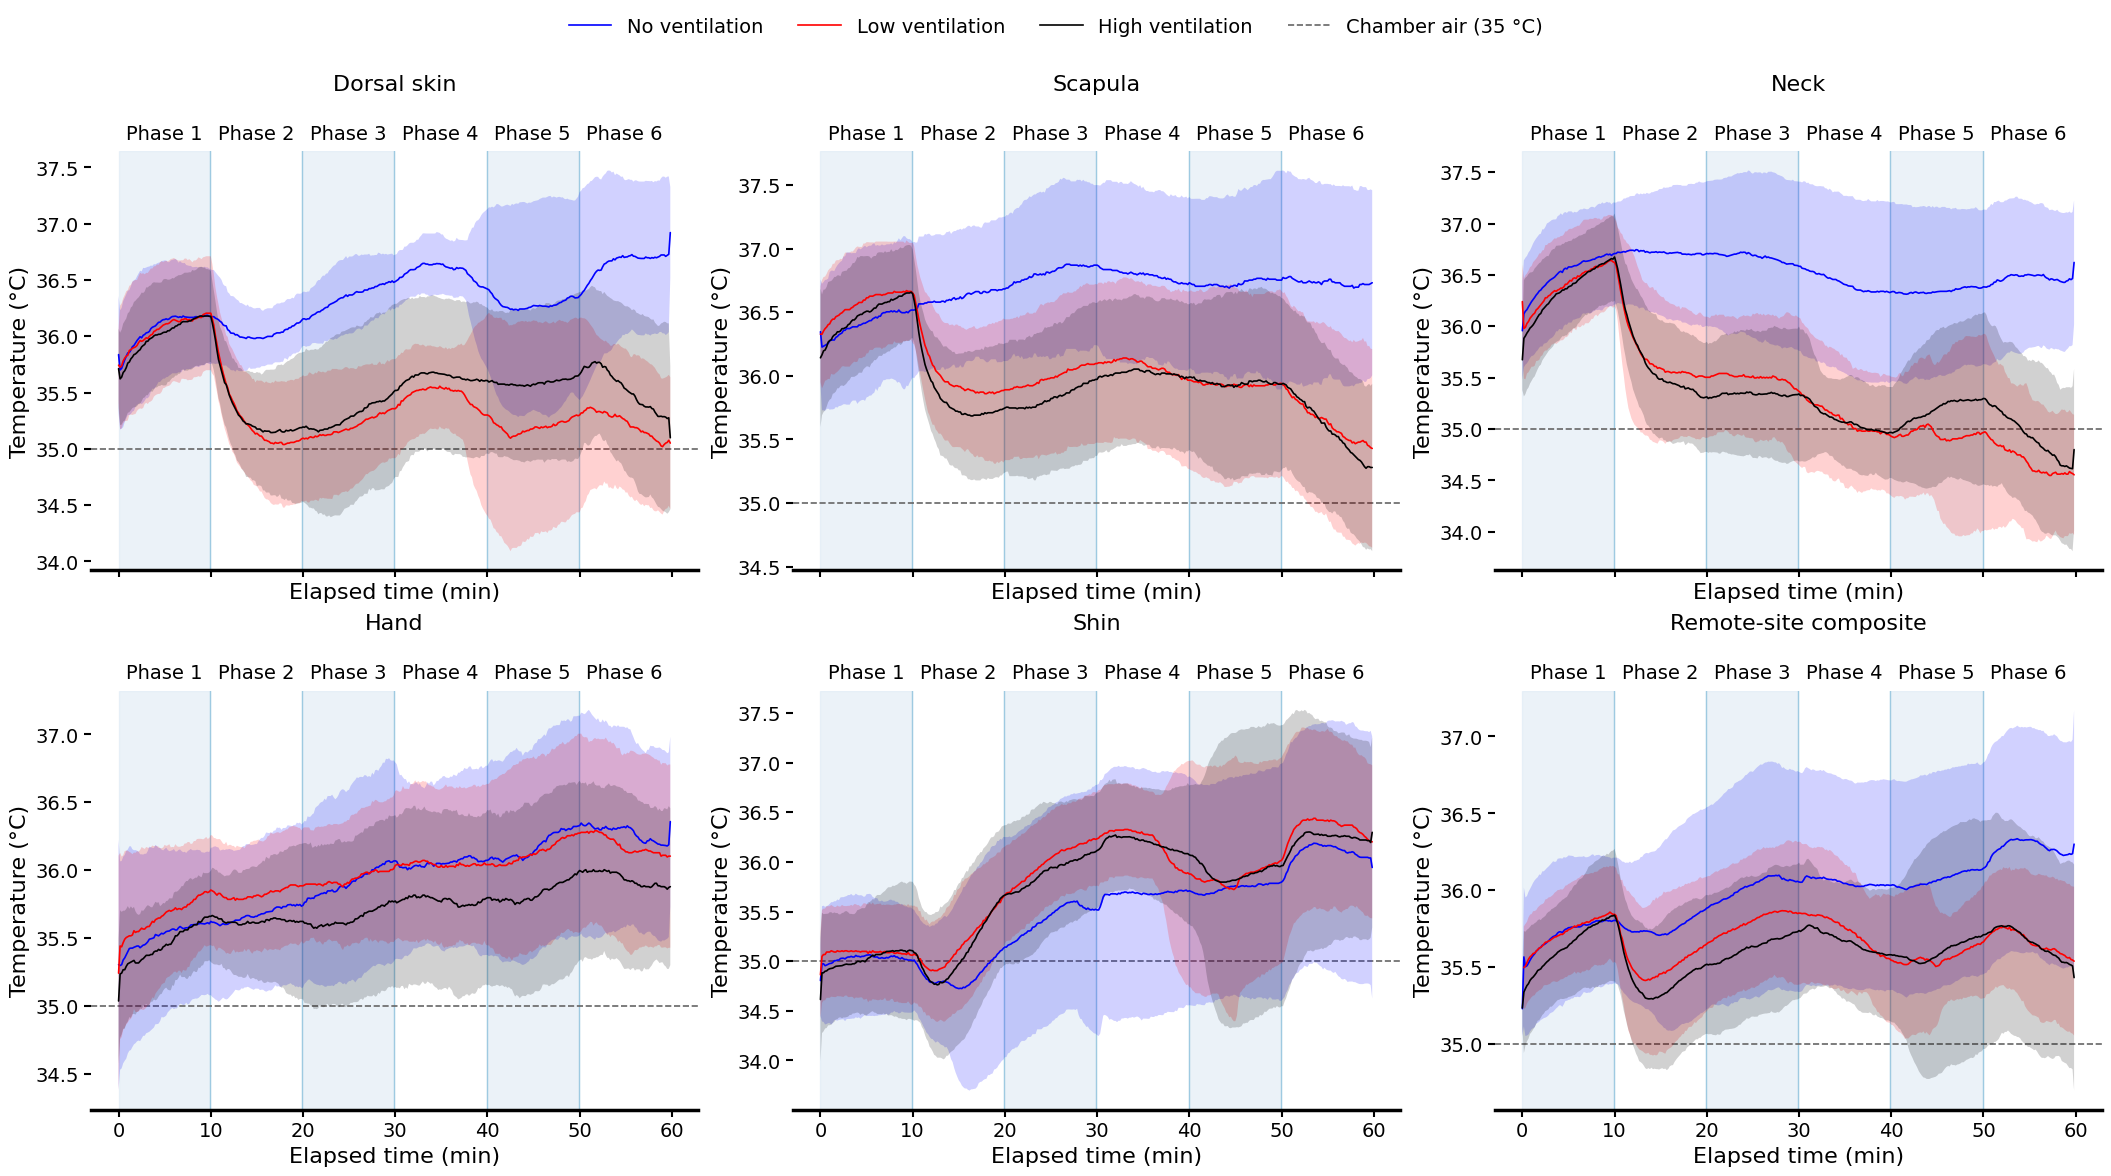

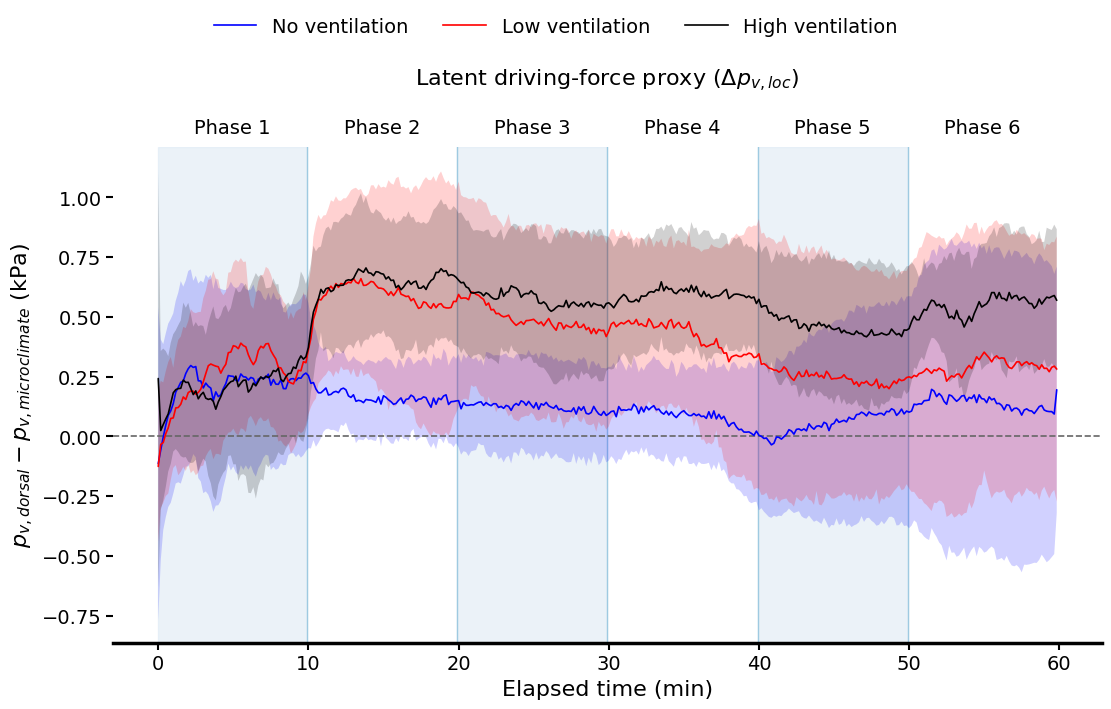

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
from pathlib import Path


# Chronological order of the six experimental phases.
PHASE_ORDER = [
    "standing_1",
    "walk_low_1",
    "walk_mod_1",
    "walk_low_2",
    "walk_mod_2",
    "standing_2",
]


PHASE_LABELS = {
    phase: f"Phase {i}"
    for i, phase in enumerate(PHASE_ORDER, start=1)
}


SIGNAL_CANDIDATES = {
    ("Dorsal", "Temperature"): ["t_dorsal"],
    ("Skin", "Temperature"): ["mean_skin_temperature"],
    ("Microclimate", "Temperature"): ["t_microclimateback"],
    ("Dorsal", "Relative humidity"): ["rh_dorsal"],
    ("Skin", "Relative humidity"): ["mean_skin_relative_humidity"],
    ("Microclimate", "Relative humidity"): ["rh_microclimateback"],
}


CONDITION_STYLE = {
    "no ventilation": {
        "color": "blue",
        "label": "No ventilation",
    },
    "low ventilation": {
        "color": "red",
        "label": "Low ventilation",
    },
    "high ventilation": {
        "color": "black",
        "label": "High ventilation",
    },
}


# Temporal resolution of the common interpolation grid.
TIME_BIN_SECONDS = 10
MAX_PLOT_INTERPOLATION_GAP_SECONDS = 30

# Controlled chamber conditions. Change these values here if the measured
# chamber averages, rather than the nominal set points, are to be displayed.
AMBIENT_TEMPERATURE_C = 35.0
AMBIENT_RH_PERCENT = 50.0

# Remove only isolated one-sample artefacts before plotting.
# A value is replaced only when the observations immediately before and
# after it are mutually consistent, while the central value departs from
# their time-interpolated value by more than the stated threshold.
TEMPERATURE_SPIKE_THRESHOLD_C = 0.20
RH_SPIKE_THRESHOLD_PERCENT = 3.0
MAX_SPIKE_NEIGHBOUR_GAP_SECONDS = 20

# Save publication-ready copies as well as displaying the figures.
SAVE_FIGURES = True
FIGURE_OUTPUT_DIRECTORY = Path("figures/absolute_thermal_state")


# Location of the processed dataset relative to the project root.
DATASET_RELATIVE_PATH = Path(
    "data/processed/analysis/analysis_dataset_wide.csv"
)


# ISO 9886:2004 four-site weighting scheme for warm environments.
SKIN_TEMPERATURE_WEIGHTS = {
    "t_neck": 0.28,
    "t_scapula": 0.28,
    "t_hand": 0.16,
    "t_shin": 0.28,
}


def find_input_file():
    """
    Search for the processed dataset starting from the current
    directory and moving upward through its parent directories.
    """
    current_directory = Path.cwd().resolve()

    directories_to_search = [
        current_directory,
        *current_directory.parents,
    ]

    searched_paths = []

    for directory in directories_to_search:
        candidate = directory / DATASET_RELATIVE_PATH
        searched_paths.append(candidate)

        if candidate.is_file():
            return candidate

    searched_text = "\n".join(
        f"  - {path}"
        for path in searched_paths
    )

    raise FileNotFoundError(
        "Could not find analysis_dataset_wide.csv.\n"
        "The following locations were searched:\n"
        f"{searched_text}"
    )


def load_data():
    """
    Load and standardise the processed experimental dataset.
    """
    input_file = find_input_file()

    print(f"Loading data from: {input_file}")

    data = pd.read_csv(input_file)

    required_columns = {
        "subject_id",
        "condition",
        "phase",
    }

    missing_columns = sorted(
        required_columns - set(data.columns)
    )

    if missing_columns:
        raise KeyError(
            "Required dataset columns are missing: "
            f"{missing_columns}"
        )

    numeric_columns = [
        "elapsed_seconds",
        "elapsed_minutes",
        *SKIN_TEMPERATURE_WEIGHTS.keys(),
    ]

    for column in numeric_columns:
        if column in data.columns:
            data[column] = pd.to_numeric(
                data[column],
                errors="coerce",
            )

    # Generate elapsed time in seconds if only minutes are available.
    if "elapsed_seconds" not in data.columns:
        if "elapsed_minutes" not in data.columns:
            raise KeyError(
                "The dataset must contain either "
                "'elapsed_seconds' or 'elapsed_minutes'."
            )

        data["elapsed_seconds"] = (
            data["elapsed_minutes"] * 60
        )

    # Generate elapsed time in minutes if only seconds are available.
    if "elapsed_minutes" not in data.columns:
        data["elapsed_minutes"] = (
            data["elapsed_seconds"] / 60
        )

    data["condition"] = (
        data["condition"]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    data["subject_id"] = (
        data["subject_id"]
        .astype(str)
        .str.strip()
    )

    data["phase"] = (
        data["phase"]
        .astype(str)
        .str.strip()
    )

    return data



def replace_isolated_spikes(
    data,
    signal_columns,
    threshold_by_column,
    max_neighbour_gap_seconds=20,
):
    """
    Replace isolated one-sample spikes without smoothing sustained changes.

    Cleaning is carried out separately for each participant and ventilation
    condition on the original chronological record. Phase boundaries are not
    used as cleaning boundaries, because several isolated artefacts occur at
    those exact timestamps. A point is replaced only when:

      1. the preceding and following observations are both available;
      2. each neighbour is no more than `max_neighbour_gap_seconds` away;
      3. the two neighbours differ by no more than the signal threshold; and
      4. the central observation differs from their time-interpolated value
         by more than the same threshold.

    Consequently, a real transition persisting for two or more observations
    is retained. The raw input file is never modified. An audit table with
    every replacement is returned together with the cleaned dataframe.
    """
    cleaned = data.copy()
    audit_rows = []

    available_signals = [
        column for column in signal_columns if column in cleaned.columns
    ]
    cleaned[available_signals] = cleaned[available_signals].apply(
        pd.to_numeric,
        errors="coerce",
    )

    group_columns = ["subject_id", "condition"]
    for group_key, group in cleaned.groupby(
        group_columns,
        observed=True,
        sort=False,
    ):
        ordered = group.sort_values("elapsed_seconds")
        row_indices = ordered.index.to_numpy()
        times = ordered["elapsed_seconds"].to_numpy(dtype=float)

        if len(ordered) < 3:
            continue

        for signal in available_signals:
            threshold = float(threshold_by_column[signal])
            values = ordered[signal].to_numpy(dtype=float)

            previous = values[:-2]
            current = values[1:-1]
            following = values[2:]
            t_previous = times[:-2]
            t_current = times[1:-1]
            t_following = times[2:]

            dt_previous = t_current - t_previous
            dt_following = t_following - t_current
            total_dt = t_following - t_previous

            finite = (
                np.isfinite(previous)
                & np.isfinite(current)
                & np.isfinite(following)
                & np.isfinite(t_previous)
                & np.isfinite(t_current)
                & np.isfinite(t_following)
                & (total_dt > 0)
            )
            close_in_time = (
                (dt_previous > 0)
                & (dt_following > 0)
                & (dt_previous <= max_neighbour_gap_seconds)
                & (dt_following <= max_neighbour_gap_seconds)
            )

            expected = previous + (
                (following - previous)
                * (t_current - t_previous)
                / total_dt
            )
            neighbours_consistent = (
                np.abs(following - previous) <= threshold
            )
            central_deviation = np.abs(current - expected)

            spike_mask = (
                finite
                & close_in_time
                & neighbours_consistent
                & (central_deviation > threshold)
            )

            for local_position in np.flatnonzero(spike_mask):
                source_position = local_position + 1
                row_index = row_indices[source_position]
                replacement = float(expected[local_position])
                original = float(current[local_position])

                cleaned.at[row_index, signal] = replacement
                audit_rows.append(
                    {
                        "subject_id": group_key[0],
                        "condition": group_key[1],
                        "phase": cleaned.at[row_index, "phase"],
                        "elapsed_seconds": float(times[source_position]),
                        "signal": signal,
                        "original_value": original,
                        "replacement_value": replacement,
                        "absolute_correction": abs(original - replacement),
                    }
                )

    audit = pd.DataFrame(audit_rows)
    return cleaned, audit

def add_mean_skin_temperature(data):
    """
    Calculate ISO-weighted mean skin temperature.
    """
    missing_columns = [
        column
        for column in SKIN_TEMPERATURE_WEIGHTS
        if column not in data.columns
    ]

    if missing_columns:
        raise KeyError(
            "The ISO-weighted mean skin temperature "
            "requires the following missing columns: "
            f"{missing_columns}"
        )

    data = data.copy()

    temperature_columns = list(
        SKIN_TEMPERATURE_WEIGHTS
    )

    data[temperature_columns] = (
        data[temperature_columns]
        .apply(pd.to_numeric, errors="coerce")
    )

    weighted_temperature = sum(
        data[column] * weight
        for column, weight
        in SKIN_TEMPERATURE_WEIGHTS.items()
    )

    # Return NaN whenever at least one of the four required
    # temperature measurements is unavailable.
    all_measurements_available = (
        data[temperature_columns]
        .notna()
        .all(axis=1)
    )

    data["mean_skin_temperature"] = (
        weighted_temperature.where(
            all_measurements_available
        )
    )

    return data


def canonical_condition(value):
    value = (
        str(value)
        .strip()
        .lower()
        .replace("_", " ")
        .replace("-", " ")
    )

    value = " ".join(value.split())

    if value in {
        "no",
        "none",
        "off",
        "no wind",
        "no ventilation",
        "without ventilation",
    }:
        return "no ventilation"

    if value in {
        "low",
        "wind low",
        "low wind",
        "low ventilation",
    }:
        return "low ventilation"

    if value in {
        "high",
        "wind high",
        "high wind",
        "high ventilation",
    }:
        return "high ventilation"

    return value


def resolve_signals(columns):
    lookup = {
        str(column).lower(): column
        for column in columns
    }

    resolved = {}
    missing = {}

    for key, candidates in SIGNAL_CANDIDATES.items():
        match = next(
            (
                lookup[name.lower()]
                for name in candidates
                if name.lower() in lookup
            ),
            None,
        )

        if match is None:
            missing[key] = candidates
        else:
            resolved[key] = match

    if missing:
        details = "\n".join(
            f"  {key}: {names}"
            for key, names in missing.items()
        )

        raise KeyError(
            "Signals not found:\n"
            f"{details}\n\n"
            f"Available columns:\n{list(columns)}"
        )

    return resolved


def phase_intervals(frame):
    intervals = []

    for phase in PHASE_ORDER:
        values = pd.to_numeric(
            frame.loc[
                frame["phase"] == phase,
                "elapsed_minutes",
            ],
            errors="coerce",
        ).dropna()

        if not values.empty:
            intervals.append(
                (
                    phase,
                    float(values.min()),
                    float(values.max()),
                )
            )

    if len(intervals) > 1:
        boundaries = [
            (intervals[i][2] + intervals[i + 1][1]) / 2
            for i in range(len(intervals) - 1)
        ]

        starts = [intervals[0][1], *boundaries]
        ends = [*boundaries, intervals[-1][2]]

        intervals = [
            (interval[0], start, end)
            for interval, start, end in zip(
                intervals,
                starts,
                ends,
            )
        ]

    return intervals


# Load the raw processed dataset, remove isolated one-sample artefacts,
# and only then calculate composite and derived quantities.
plot_data = load_data()

raw_temperature_columns = [
    column for column in plot_data.columns if column.startswith("t_")
]
raw_rh_columns = [
    column for column in plot_data.columns if column.startswith("rh_")
]
spike_thresholds = {
    **{
        column: TEMPERATURE_SPIKE_THRESHOLD_C
        for column in raw_temperature_columns
    },
    **{
        column: RH_SPIKE_THRESHOLD_PERCENT
        for column in raw_rh_columns
    },
}

plot_data, spike_audit = replace_isolated_spikes(
    plot_data,
    signal_columns=[*raw_temperature_columns, *raw_rh_columns],
    threshold_by_column=spike_thresholds,
    max_neighbour_gap_seconds=MAX_SPIKE_NEIGHBOUR_GAP_SECONDS,
)

if spike_audit.empty:
    print("No isolated one-sample artefacts were detected.")
else:
    print(
        f"Replaced {len(spike_audit)} isolated one-sample artefacts "
        "before plotting."
    )
    audit_output = Path("outputs/isolated_spike_audit.csv")
    audit_output.parent.mkdir(parents=True, exist_ok=True)
    spike_audit.to_csv(audit_output, index=False)
    print(f"Spike audit saved to: {audit_output}")

plot_data = add_mean_skin_temperature(plot_data)


# Calculate mean skin RH as the arithmetic mean of all skin sensors.
# The ISO 9886 temperature weights are not applied to RH.
SKIN_RH_COLUMNS = [
    "rh_hand",
    "rh_chest",
    "rh_scapula",
    "rh_abdomen",
    "rh_dorsal",
    "rh_shin",
    "rh_neck",
]


missing_skin_rh = [
    column
    for column in SKIN_RH_COLUMNS
    if column not in plot_data.columns
]

if missing_skin_rh:
    raise KeyError(
        "Columns needed to calculate mean skin RH are missing: "
        f"{missing_skin_rh}"
    )


plot_data["mean_skin_relative_humidity"] = (
    plot_data[SKIN_RH_COLUMNS]
    .apply(pd.to_numeric, errors="coerce")
    .mean(axis=1)
)


# Exploratory temperature descriptor for skin sites not directly exposed to
# the dorsal fans. This is not the ISO 9886 mean skin temperature.
REMOTE_SKIN_WEIGHTS = {
    "t_neck": 0.28,
    "t_hand": 0.16,
    "t_shin": 0.28,
}

remote_columns = list(REMOTE_SKIN_WEIGHTS)
plot_data[remote_columns] = plot_data[remote_columns].apply(
    pd.to_numeric,
    errors="coerce",
)
remote_weight_sum = sum(REMOTE_SKIN_WEIGHTS.values())
remote_temperature = sum(
    plot_data[column] * weight
    for column, weight in REMOTE_SKIN_WEIGHTS.items()
) / remote_weight_sum
plot_data["remote_skin_temperature"] = remote_temperature.where(
    plot_data[remote_columns].notna().all(axis=1)
)


def saturation_vapour_pressure_kpa(temperature_c):
    """Magnus equation; input in degC and output in kPa."""
    temperature_c = pd.to_numeric(temperature_c, errors="coerce")
    return 0.61078 * np.exp(
        17.27 * temperature_c / (temperature_c + 237.3)
    )


required_derived_columns = [
    "t_dorsal",
    "t_microclimateback",
    "rh_dorsal",
    "rh_microclimateback",
]
missing_derived_columns = [
    column
    for column in required_derived_columns
    if column not in plot_data.columns
]
if missing_derived_columns:
    raise KeyError(
        "Columns needed for the thermal-state analysis are missing: "
        f"{missing_derived_columns}"
    )

plot_data[required_derived_columns] = plot_data[
    required_derived_columns
].apply(pd.to_numeric, errors="coerce")

plot_data["delta_t_loc"] = (
    plot_data["t_dorsal"] - plot_data["t_microclimateback"]
)
plot_data["pv_dorsal_kpa"] = (
    plot_data["rh_dorsal"] / 100.0
) * saturation_vapour_pressure_kpa(plot_data["t_dorsal"])
plot_data["pv_microclimate_kpa"] = (
    plot_data["rh_microclimateback"] / 100.0
) * saturation_vapour_pressure_kpa(plot_data["t_microclimateback"])
plot_data["delta_pv_loc_kpa"] = (
    plot_data["pv_dorsal_kpa"]
    - plot_data["pv_microclimate_kpa"]
)

AMBIENT_VAPOUR_PRESSURE_KPA = float(
    AMBIENT_RH_PERCENT
    / 100.0
    * saturation_vapour_pressure_kpa(
        pd.Series([AMBIENT_TEMPERATURE_C])
    ).iloc[0]
)


# Standardise ventilation-condition names.
plot_data["condition_plot"] = (
    plot_data["condition"].map(canonical_condition)
)


unknown_conditions = sorted(
    set(plot_data["condition_plot"].dropna())
    - set(CONDITION_STYLE)
)

if unknown_conditions:
    raise ValueError(
        f"Unrecognised conditions: {unknown_conditions}. "
        "Update canonical_condition()."
    )


# Create common 10-second time bins.
# This prevents artificial high-frequency oscillations caused by
# participants having samples recorded at slightly different times.
# Convert elapsed time to numeric seconds.
if "elapsed_seconds" in plot_data.columns:
    plot_data["elapsed_seconds"] = pd.to_numeric(
        plot_data["elapsed_seconds"],
        errors="coerce",
    )
else:
    plot_data["elapsed_seconds"] = (
        pd.to_numeric(
            plot_data["elapsed_minutes"],
            errors="coerce",
        )
        * 60
    )


# Common temporal grid shared by all participants.
common_time_s = np.arange(
    0,
    plot_data["elapsed_seconds"].max() + TIME_BIN_SECONDS,
    TIME_BIN_SECONDS,
)
phase_ranges = phase_intervals(plot_data)


def interpolate_by_subject_and_phase(frame, signal, condition):
    """Return subject trajectories on a common grid.

    Only short internal gaps are interpolated. The interpolation is allowed
    across a phase boundary because the sensor record itself is continuous;
    this prevents the group mean from jumping merely because a participant
    has no sample at one boundary-adjacent grid point. Long gaps remain NaN.
    """
    subset = frame.loc[
        frame["condition_plot"] == condition,
        ["subject_id", "elapsed_seconds", signal],
    ].copy()
    subset[signal] = pd.to_numeric(subset[signal], errors="coerce")
    subset = subset.dropna(
        subset=["subject_id", "elapsed_seconds", signal]
    )

    subject_rows = []
    for subject_id, subject_data in subset.groupby(
        "subject_id", observed=True
    ):
        series = (
            subject_data.groupby(
                "elapsed_seconds", observed=True, as_index=False
            )[signal]
            .mean()
            .sort_values("elapsed_seconds")
        )
        observed_time = series["elapsed_seconds"].to_numpy(float)
        observed_values = series[signal].to_numpy(float)
        subject_series = np.full(common_time_s.shape, np.nan, dtype=float)

        if len(observed_time) < 2:
            subject_rows.append(subject_series)
            continue

        right = np.searchsorted(observed_time, common_time_s, side="left")
        exact = (
            (right < len(observed_time))
            & (observed_time[np.minimum(right, len(observed_time) - 1)]
               == common_time_s)
        )
        exact_indices = right[exact]
        subject_series[exact] = observed_values[exact_indices]

        internal = (~exact) & (right > 0) & (right < len(observed_time))
        internal_positions = np.flatnonzero(internal)
        left_indices = right[internal] - 1
        right_indices = right[internal]
        gaps = observed_time[right_indices] - observed_time[left_indices]
        short_gap = gaps <= MAX_PLOT_INTERPOLATION_GAP_SECONDS

        if np.any(short_gap):
            positions = internal_positions[short_gap]
            left_ok = left_indices[short_gap]
            right_ok = right_indices[short_gap]
            fraction = (
                (common_time_s[positions] - observed_time[left_ok])
                / (observed_time[right_ok] - observed_time[left_ok])
            )
            subject_series[positions] = (
                observed_values[left_ok]
                + fraction
                * (observed_values[right_ok] - observed_values[left_ok])
            )

        subject_rows.append(subject_series)

    if not subject_rows:
        return None
    return np.vstack(subject_rows)

def add_phase_background(ax, show_phase_labels=True):
    for phase_index, (phase, start, end) in enumerate(phase_ranges):
        if phase_index % 2 == 0:
            ax.axvspan(
                start, end, color="#dbe9f4", alpha=0.55, zorder=0
            )
        if phase_index > 0:
            ax.axvline(start, color="#9ecae1", linewidth=1.0, zorder=1)
        if show_phase_labels:
            ax.text(
                (start + end) / 2,
                1.02,
                PHASE_LABELS[phase],
                transform=ax.get_xaxis_transform(),
                ha="center",
                va="bottom",
                fontsize=14,
                clip_on=False,
            )


def format_axis(ax, title, ylabel, show_phase_labels=True):
    add_phase_background(ax, show_phase_labels=show_phase_labels)
    ax.set_title(title, fontsize=16, pad=44 if show_phase_labels else 14)
    ax.set_ylabel(ylabel, fontsize=16)
    ax.set_xlabel("Elapsed time (min)", fontsize=16)
    ax.tick_params(
        axis="both", which="major", labelsize=14, width=1.5, length=5
    )
    for spine in ["left", "right", "top"]:
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_linewidth(2.5)
    ax.grid(False)


def plot_group_series(ax, signal):
    for condition, style in CONDITION_STYLE.items():
        subject_matrix = interpolate_by_subject_and_phase(
            plot_data, signal, condition
        )
        if subject_matrix is None:
            continue

        with np.errstate(invalid="ignore", divide="ignore"):
            mean = np.nanmean(subject_matrix, axis=0)
            sd = np.nanstd(subject_matrix, axis=0, ddof=1)
        n_subjects = np.sum(np.isfinite(subject_matrix), axis=0)
        valid = np.isfinite(mean) & np.isfinite(sd) & (n_subjects >= 2)
        x = common_time_s[valid] / 60.0

        ax.fill_between(
            x,
            mean[valid] - sd[valid],
            mean[valid] + sd[valid],
            color=style["color"],
            alpha=0.18,
            linewidth=0,
            edgecolor="none",
            zorder=2,
        )
        ax.plot(
            x,
            mean[valid],
            color=style["color"],
            linewidth=1.2,
            solid_capstyle="round",
            solid_joinstyle="round",
            antialiased=True,
            zorder=3,
        )


legend_handles = [
    Line2D(
        [0],
        [0],
        color=style["color"],
        linewidth=1.2,
        label=style["label"],
    )
    for style in CONDITION_STYLE.values()
]

ambient_temperature_handle = Line2D(
    [0], [0], color="#666666", linestyle="--", linewidth=1.2,
    label=f"Chamber air ({AMBIENT_TEMPERATURE_C:.0f} °C)",
)
ambient_vapour_handle = Line2D(
    [0], [0], color="#666666", linestyle="--", linewidth=1.2,
    label="Chamber-air vapour pressure",
)



def add_figure_legend(fig, handles, ncol=None, y=1.015):
    """Place one shared legend above the axes without reducing panel width."""
    if ncol is None:
        ncol = len(handles)
    fig.legend(
        handles=handles,
        frameon=False,
        fontsize=14,
        loc="lower center",
        bbox_to_anchor=(0.5, y),
        ncol=ncol,
        columnspacing=1.8,
        handlelength=2.2,
    )

def save_and_show(fig, filename):
    if SAVE_FIGURES:
        FIGURE_OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)
        fig.savefig(
            FIGURE_OUTPUT_DIRECTORY / f"{filename}.png",
            dpi=600,
            bbox_inches="tight",
        )
        fig.savefig(
            FIGURE_OUTPUT_DIRECTORY / f"{filename}.pdf",
            bbox_inches="tight",
        )
    plt.show()


# -------------------------------------------------------------------------
# FIGURE 1 — Main paper: absolute thermal state and sensible driving force.
# -------------------------------------------------------------------------
fig1, axes1 = plt.subplots(
    2, 2, figsize=(16, 11), sharex=True, constrained_layout=True
)
main_panels = [
    (axes1[0, 0], "t_dorsal", "Dorsal skin", "Temperature (°C)", True),
    (
        axes1[0, 1],
        "t_microclimateback",
        "Back microclimate",
        "Temperature (°C)",
        True,
    ),
    (
        axes1[1, 0],
        "delta_t_loc",
        r"Sensible driving-force proxy ($\Delta T_{loc}$)",
        r"$T_{dorsal}-T_{microclimate}$ (°C)",
        False,
    ),
    (
        axes1[1, 1],
        "mean_skin_temperature",
        "ISO-weighted mean skin",
        "Temperature (°C)",
        True,
    ),
]

for ax, signal, title, ylabel, ambient_line in main_panels:
    format_axis(ax, title, ylabel)
    plot_group_series(ax, signal)
    if ambient_line:
        ax.axhline(
            AMBIENT_TEMPERATURE_C,
            color="#666666",
            linestyle="--",
            linewidth=1.2,
            zorder=1,
        )
    if signal == "delta_t_loc":
        ax.axhline(0, color="#666666", linestyle="--", linewidth=1.2)

add_figure_legend(
    fig1,
    [*legend_handles, ambient_temperature_handle],
)
save_and_show(fig1, "main_absolute_thermal_state")


# -------------------------------------------------------------------------
# FIGURE 2 — Main/Supplementary: microclimate heat and moisture state.
# Vapour pressure is included because RH alone changes with temperature.
# -------------------------------------------------------------------------
fig2, axes2 = plt.subplots(
    1, 3, figsize=(21, 6.4), sharex=True, constrained_layout=True
)
microclimate_panels = [
    (
        axes2[0],
        "t_microclimateback",
        "Microclimate temperature",
        "Temperature (°C)",
    ),
    (
        axes2[1],
        "rh_microclimateback",
        "Microclimate relative humidity",
        "Relative humidity (%)",
    ),
    (
        axes2[2],
        "pv_microclimate_kpa",
        "Microclimate vapour pressure",
        "Vapour pressure (kPa)",
    ),
]

for ax, signal, title, ylabel in microclimate_panels:
    format_axis(ax, title, ylabel)
    plot_group_series(ax, signal)

axes2[0].axhline(
    AMBIENT_TEMPERATURE_C,
    color="#666666",
    linestyle="--",
    linewidth=1.2,
)
axes2[1].axhline(
    AMBIENT_RH_PERCENT,
    color="#666666",
    linestyle="--",
    linewidth=1.2,
)
axes2[2].axhline(
    AMBIENT_VAPOUR_PRESSURE_KPA,
    color="#666666",
    linestyle="--",
    linewidth=1.2,
)
chamber_reference_handle = Line2D(
    [0], [0], color="#666666", linestyle="--", linewidth=1.2,
    label="Chamber-air reference",
)
add_figure_legend(
    fig2,
    [*legend_handles, chamber_reference_handle],
)
save_and_show(fig2, "microclimate_heat_and_moisture_state")


# -------------------------------------------------------------------------
# FIGURE 3 — Supplementary: local versus remote cutaneous response.
# The remote-site composite excludes scapula and is not an ISO mean.
# -------------------------------------------------------------------------
fig3, axes3 = plt.subplots(
    2, 3, figsize=(21, 11), sharex=True, constrained_layout=True
)
site_panels = [
    (axes3[0, 0], "t_dorsal", "Dorsal skin"),
    (axes3[0, 1], "t_scapula", "Scapula"),
    (axes3[0, 2], "t_neck", "Neck"),
    (axes3[1, 0], "t_hand", "Hand"),
    (axes3[1, 1], "t_shin", "Shin"),
    (
        axes3[1, 2],
        "remote_skin_temperature",
        "Remote-site composite",
    ),
]

for ax, signal, title in site_panels:
    if signal not in plot_data.columns:
        raise KeyError(f"Signal required for local/remote analysis: {signal}")
    format_axis(ax, title, "Temperature (°C)")
    plot_group_series(ax, signal)
    ax.axhline(
        AMBIENT_TEMPERATURE_C,
        color="#666666",
        linestyle="--",
        linewidth=1.2,
        zorder=1,
    )

add_figure_legend(
    fig3,
    [*legend_handles, ambient_temperature_handle],
)
save_and_show(fig3, "supplementary_local_vs_remote_skin_temperature")


# -------------------------------------------------------------------------
# FIGURE 4 — Supplementary: latent driving-force proxy.
# -------------------------------------------------------------------------
fig4, ax4 = plt.subplots(figsize=(11, 6.4), constrained_layout=True)
format_axis(
    ax4,
    r"Latent driving-force proxy ($\Delta p_{v,loc}$)",
    r"$p_{v,dorsal}-p_{v,microclimate}$ (kPa)",
)
plot_group_series(ax4, "delta_pv_loc_kpa")
ax4.axhline(0, color="#666666", linestyle="--", linewidth=1.2)
add_figure_legend(fig4, legend_handles)
save_and_show(fig4, "supplementary_latent_driving_force")
